# Import Library

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Load Dataset

In [10]:
data = pd.read_csv('JumlahDesa.csv', index_col=0)
data

,id_index,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,periode_update,kategori,jumlah,satuan,tahun
id,,,,,,,,,,
1,5,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,TERTINGGAL,8,DESA,2019
1,4,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,SANGAT TERTINGGAL,0,DESA,2019
1,2,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MAJU,24,DESA,2019
1,1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,BERKEMBANG,249,DESA,2019
1,3,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MANDIRI,0,DESA,2019
...,...,...,...,...,...,...,...,...,...,...
305,1335,35,JAWA TIMUR,3579,KOTA BATU,2024,TERTINGGAL,0,DESA,2024
305,1331,35,JAWA TIMUR,3579,KOTA BATU,2024,BERKEMBANG,0,DESA,2024
305,1332,35,JAWA TIMUR,3579,KOTA BATU,2024,MAJU,0,DESA,2024


# check missing value

In [11]:
data.isnull().sum()

id_index               0
kode_provinsi          0
nama_provinsi          0
kode_kabupaten_kota    0
nama_kabupaten_kota    0
periode_update         0
kategori               0
jumlah                 0
satuan                 0
tahun                  0
dtype: int64

# Handling Missing Value

In [12]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data

,id_index,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,periode_update,kategori,jumlah,satuan,tahun
id,,,,,,,,,,
1,5,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,TERTINGGAL,8,DESA,2019
1,4,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,SANGAT TERTINGGAL,0,DESA,2019
1,2,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MAJU,24,DESA,2019
1,1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,BERKEMBANG,249,DESA,2019
1,3,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2019,MANDIRI,0,DESA,2019
...,...,...,...,...,...,...,...,...,...,...
305,1335,35,JAWA TIMUR,3579,KOTA BATU,2024,TERTINGGAL,0,DESA,2024
305,1331,35,JAWA TIMUR,3579,KOTA BATU,2024,BERKEMBANG,0,DESA,2024
305,1332,35,JAWA TIMUR,3579,KOTA BATU,2024,MAJU,0,DESA,2024


# EDA Timeseries

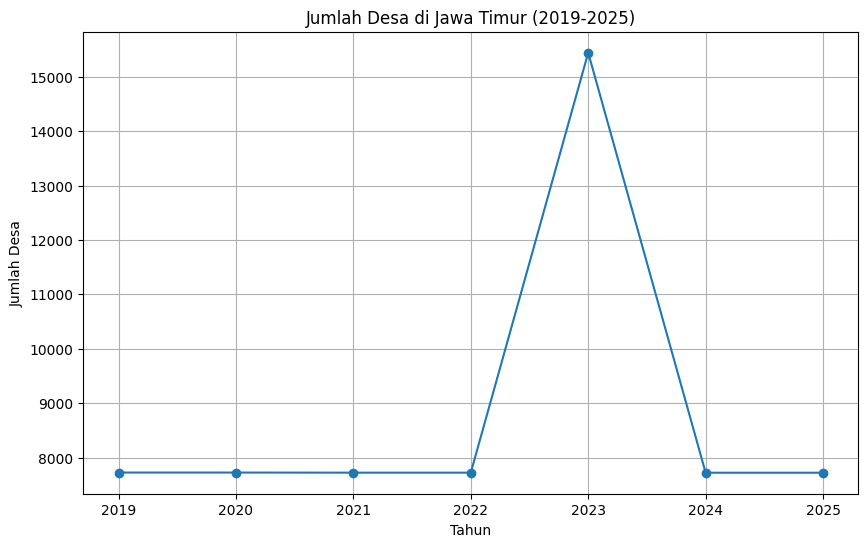

In [14]:
ts = data.groupby('tahun')['jumlah'].sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(ts['tahun'], ts['jumlah'], marker='o')
plt.title('Jumlah Desa di Jawa Timur (2019-2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Desa')
plt.grid(True)

plt.show()

# forecasting with  SMA (Simple movig average)

In [17]:
data['sma'] = data['jumlah'].rolling(window=4).mean()
print(data[('sma')])

id
1        NaN
1        NaN
1        NaN
1      70.25
1      68.25
       ...  
305     0.00
305     0.00
305     0.00
305     4.75
305     4.75
Name: sma, Length: 1525, dtype: float64


# Visualisasi SMA (Simple Moving Average)

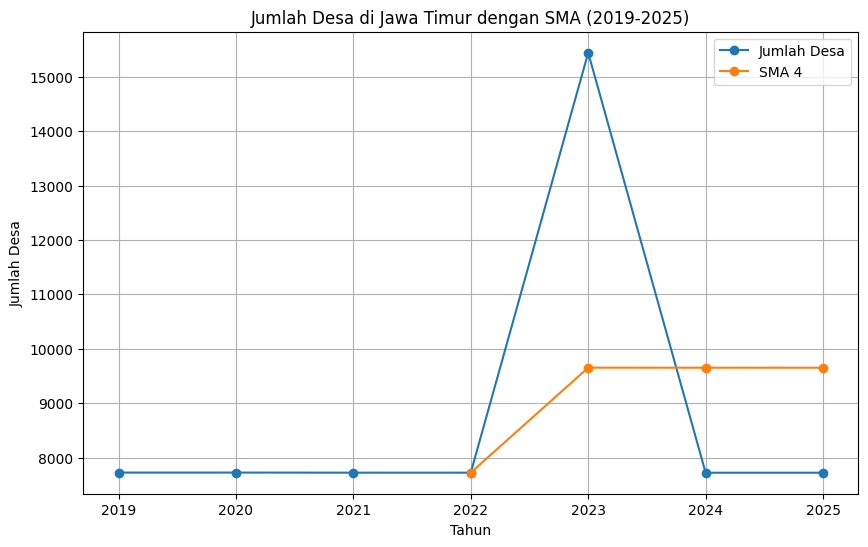

In [ ]:
ts = data.groupby('tahun')['jumlah'].sum().reset_index()
ts['sma'] = ts['jumlah'].rolling(window=4).mean()

plt.figure(figsize=(10,6))
plt.plot(ts['tahun'], ts['jumlah'], marker='o', label='Jumlah Desa')
plt.plot(ts['tahun'], ts['sma'], marker='o', label='SMA 4')

plt.title('Jumlah Desa di Jawa Timur dengan SMA (2019-2025)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Desa')
plt.grid(True)
plt.legend()
plt.show()